Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as any collaborators you worked with:

In [1]:
COLLABORATORS = ""

## To receive credit for this assignment, you must also fill out the [AI Use survey](https://forms.gle/ZhR5k8TdAeN8rj4CA)


---

In [2]:
%matplotlib inline
%precision 16
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Final Project

This notebook will provide a brief structure and rubric for presenting your final project. 

The purpose of the project is 2-fold
* To give you an opportunity to work on a problem you are truly interested in (as this is the best way to actually learn something)
* To demonstrate to me that you understand the overall workflow of problem solving from problem selection to implementation to discussion 

You can choose any subject area that interests you as long as there is a computational component to it.  However, please do not reuse projects or homeworks you have done in other classes.  This should be **your** original work.

**You can work in teams, but clearly identify each persons contribution** and every team member should hand in their own copy of the notebook.

### Structure
There are 5 parts for a total of 100 points that provide the overall structure of a mini research project.

* Abstract
* Introduction and Problem Description
* Brief discussion of Computational approach and import of any additional packages
* Implementation including tests
* Discussion of results and future directions

For grading purposes, please try to make this notebook entirely self contained. 

The project is worth about 2 problem sets and should be of comparable length (please: I will have about 100 of these to read and I am not expecting full 10 page papers).  The actual project does not necessarily have to work but in that case you should demonstrate that you understand why it did not work and what steps you would take next to fix it.

Have fun

## Abstract [10 pts]

Provide a 1-2 paragraph abstract of the project in the style of a research paper.  The abstract should contain

* A brief description of the problem
* A brief justification describing why this problem is important/interesting to you
* A general description of the computational approach
* A brief summary of what you did and what you learned


Motor-imagery (MI) decoding from EEG is a canonical brain–computer interface (BCI) problem, but practical MI BCIs are limited by label scarcity and domain shift: models trained on large public datasets often fail on a new user or on consumer-grade headsets.

In this project, I built an end-to-end, reproducible comparison between (i) classical EEG decoding baselines (Riemannian covariance models / tangent-space models) and (ii) a hybrid deep architecture that combines a CNN encoder for raw time-series with a lightweight feature branch (CSP features) and Transformer-style sequence modeling. I then evaluated **from-scratch training** vs **transfer learning from a public MI model to my self-recorded EEG**. On my dataset, transfer learning consistently improved performance and was most beneficial in the low-data regime (e.g., using only a couple of short runs), demonstrating label-efficiency gains. I also validated results with controls (label shuffle for classical baselines) and uncertainty estimates (repeated runs / bootstrap confidence intervals).

Finally, I implemented and ran a **run-wise generalization** evaluation (leave-one-run-out across self-recorded runs). This is a stronger test than a random stratified split because it measures robustness to **run/session drift**. Under run-wise evaluation, performance varies by held-out run (evidence of nonstationarity), and **transfer learning remains best on average** while a strong classical baseline (TS+LR) remains competitive on some runs.

## Introduction [15 pts]

In ~4-5 paragraphs, describe 
* The general problem you want to solve
* Why it is important and what you hope to achieve.

Please provide basic **references**, particularly if you are reproducing results from a paper. Also include any basic equations you plan to solve. 

Please use proper spelling and grammar. 

Motor imagery BCIs aim to decode intended movement (e.g., imagined left vs. right hand) from scalp EEG, enabling control without overt motion. A central challenge is that EEG is low signal-to-noise, highly nonstationary, and varies substantially across people and recording systems. As a result, models that perform well on a standardized public dataset can fail when deployed on a new subject or a different headset.

This project focuses on **data- and domain-efficient MI decoding**. The motivating question is: *given limited labeled data from a new user on a consumer-grade headset, what is the most reliable way to obtain above-chance MI decoding?* I compare classical pipelines that are known to work well in small-data EEG (covariance-based Riemannian models and tangent-space classifiers) against a compact deep model that can leverage transfer learning from large public data.

To make the comparison meaningful, I designed a consistent offline evaluation pipeline: (1) load my self-recorded runs saved as FIF files, (2) epoch around task events, (3) apply simple filtering and CSP features, and (4) evaluate multiple model families under identical train/validation splits. I additionally measure **label efficiency** by running the same experiments on progressively larger subsets of runs (2 runs, 4 runs, 8 runs).

Critically, I also evaluate **run-wise generalization** (leave-one-run-out and prefix-run holdout). This is closer to deployment: the model must generalize from earlier runs to a later/held-out run without mixing trials randomly across runs. This evaluation exposes nonstationarity (run-to-run drift) and lets us ask whether transfer learning improves robustness under that drift.

Beyond raw accuracy, I emphasize graphical and statistical evidence: learning curves (accuracy vs. number of runs), per-run variability across repeated training runs, confusion matrices, and sanity-check controls (label-shuffle performance for classical baselines and bootstrap confidence intervals for deep models). These outputs help explain not just *whether* transfer helps, but *when* it helps and how large the gains are.

Overall, this project is a mini-research study in reproducible MI decoding: it surfaces the trade-offs between classical and deep approaches, demonstrates practical transfer learning to consumer EEG, and (via run-wise testing) directly measures robustness to run/session drift.

### References

- **MNE-Python** for EEG I/O and preprocessing: Gramfort et al., *Frontiers in Neuroscience* (2013).
- **PhysioNet EEG Motor Movement/Imagery Dataset**: Goldberger et al., *Circulation* (2000) (and associated PhysioNet documentation).
- **Common Spatial Patterns (CSP)** for MI EEG: reviewed in many BCI sources; see also Blankertz et al., *IEEE Trans. Biomed. Eng.* (2008) for related MI decoding work.
- **Riemannian geometry for covariance-based EEG decoding**: Barachant et al., *Journal of Neural Engineering* (2012).
- **Transformer sequence modeling**: Vaswani et al., *NeurIPS* (2017) (conceptual reference for attention-based sequence models).


## Computational  Methods [10 pts]

Describe the specific approach you will take to solve some concrete aspect of the general problem. 

You should  include all the numerical or computational methods you intend to use.  These can include methods or packages  we did not discuss in class but provide some reference to the method. You do not need to explain in detail how the methods work, but you should describe their basic functionality and justify your choices. 




### Data and preprocessing
- **Self-recorded EEG** was stored as MNE `.fif` raw files with event markers on channel `STI 014` (Left=1, Right=2). Runs are epoched using a fixed task-aligned window (`EPOCH_TMIN`/`EPOCH_TMAX`) and standardized to a common number of time points by truncating to the largest length divisible by 32 (to match the CNN downsampling factor).
- Basic filtering is applied (notch + bandpass), and labels are mapped to 0/1.
- For run-wise evaluation, each epoched trial is also associated with a **run ID** derived from the filename (e.g., `sub-01_run-03_online_raw.fif`).

### Classical baselines (small-data EEG)
- **MDM (Minimum Distance to Mean)** on covariance matrices in a Riemannian metric space.
- **Tangent Space + Logistic Regression (TS+LR)**: covariances are mapped to a tangent space then classified with a linear model.
- I include a **label-shuffle control** to verify that above-chance performance is not an artifact.

### Deep model
- A **hybrid CNN + sequence model** (`HybridModelClassifier`) processes raw EEG through a CNN encoder and optionally fuses handcrafted features.
- **Feature branch**: per-subject CSP features (`CSPModule`) are computed and fused with the raw branch.
- Two training regimes:
  - **Scratch**: train all parameters from random initialization.
  - **Transfer**: load a public-dataset pretrained model and fine-tune on my data; feature modules are refit on my training split to respect subject-specific statistics.

### Evaluation, uncertainty, and diagnostics
- Stratified train/validation splits are used for fast iteration.
- I additionally evaluate **run-wise generalization**:
  - **Leave-One-Run-Out (LORO)**: train on all runs except one and test on the held-out run.
  - **Holdout**: train on runs `01..k` and test on run `k+1`.
- Outputs include: per-run accuracy logs, learning curves vs. number of runs, confusion matrices, bootstrap confidence intervals, and run-wise generalization plots. These help quantify both performance and stability across repeats and across run/session drift.

**If you need to install or import any additional python packages,  please provide complete installation instructions in the code block below**


In [3]:
# Place the exported metrics file offline_metrics.csv in the same directory as this notebook. Then run the code cells below.

from pathlib import Path
import re
from IPython.display import display

## Implementation [50 pts]

Use the Markdown and Code blocks below to implement and document your methods including figures.  Only the first markdown block will be a grading cell but please add (not copy) cells in this section to organize your work. 

Please make the description of your problem readable by interlacing clear explanatory text with code (again with proper grammar and spelling). 
All code should be well described and commented.

For at least one routine you code below, you should provide a test block (e.g. using `numpy.testing` routines, or a convergence plot) to validate your code.  

An **important** component of any computational paper is to demonstrate to yourself and others that your code is producing correct results.

### Code organization
- **Experiment pipeline (self data)** lives under `experiment/`:
  - `train_offline_model.py`: loads runs, epochs, trains either classical sklearn baselines or the hybrid deep model (scratch or transfer), and logs metrics.
  - `offline_analysis.ipynb`: runs training/evaluation, aggregates results, and appends everything into a single metrics file (`offline_metrics.csv`). It also runs the **run-wise generalization** experiments (LORO and holdout).
  - `mi_riemann_probe.py`: classical Riemannian / TS baselines + label-shuffle controls + ERD plotting. (TS+LR is also evaluated under the same run-wise splits.)
  - `evaluate_mi_data.py`: run-level data quality checks (PSD, event timing, optional ERPs).

### What I ran
1) **Deep scratch vs deep transfer** (same preprocessing, same run subsets).
- I evaluated performance across run subsets (2 runs, 4 runs, 8 runs). Transfer consistently improved accuracy and was especially helpful at low data.

2) **Classical baselines**
- TS+LR performed above chance and served as a strong small-data baseline. A label-shuffle control produced near-chance performance, supporting that the classical signal is genuine.

3) **Repeatability + uncertainty**
- I ran repeated training jobs and summarized mean ± std by configuration.
- I computed bootstrap confidence intervals for accuracy on a fixed split.

4) **Diagnostics / ablations**
- I generated confusion matrices for scratch vs transfer models.
- I evaluated ablations (raw-only vs feature-only vs full) to understand what drives performance.

5) **Run-wise generalization (stronger evaluation)**
- I ran **Leave-One-Run-Out (LORO)**: train on 7 runs and test on the held-out run, repeated for each run.
- I also ran a **prefix holdout**: train on `01..k` and test on run `k+1`.
- This directly tests robustness to **run/session drift** (a stronger test than random stratified splits).

### New approach for a self-contained submission (no evaluation in this notebook)
This `project.ipynb` is designed to be self-contained and runnable **without any raw EEG data or saved model files**.

- **No evaluation happens here**: this notebook does not load `.fif` files, does not train models, and does not run inference.
- **All figures are regenerated from one exported file**: `offline_metrics.csv`.

**To reproduce the plots in this notebook:**
1) Run `experiment/offline_analysis.ipynb` to perform training/evaluation and produce `offline_metrics.csv`.
2) Copy `offline_metrics.csv` into the **same directory as this notebook**.
3) Run this notebook; it will generate the plots directly from the CSV.

### Key figures (generated from `offline_metrics.csv`)
- Random-split summary (mean ± std) across comparable configurations.
- Label-efficiency learning curve (accuracy vs. number of runs).
- **Run-wise generalization (LORO)**: accuracy by held-out run + mean ± std across held-out runs.

In [4]:
# Self-contained plotting from offline_metrics.csv (no raw data / no model eval)


# EXPECTED FILE PLACEMENT:
# Put `offline_metrics.csv` in the SAME directory as this notebook.
METRICS_CSV = Path('offline_metrics.csv')

if not METRICS_CSV.exists():
    raise FileNotFoundError(
        f"Missing {METRICS_CSV}. Place offline_metrics.csv next to this notebook and re-run."
    )

df = pd.read_csv(METRICS_CSV)

# Basic quick table
cols = ['timestamp', 'mode', 'trials', 'val_accuracy', 'notes']
display(df[cols].tail(12))


def _note_field(notes: str, key: str):
    m = re.search(fr"{re.escape(key)}=([^;]+)", str(notes))
    return m.group(1).strip() if m else None


def _note_list(notes: str, key: str):
    m = re.search(fr"{re.escape(key)}=\[(.*?)\]", str(notes))
    if not m:
        return []
    items = m.group(1).replace("'", "").split(',')
    return [x.strip() for x in items if x.strip()]


def _runs_list(notes: str):
    return _note_list(notes, 'runs')


def _is_prefix_01_to_k(runs_list):
    if not runs_list:
        return False
    try:
        ints = sorted(int(r) for r in runs_list)
    except Exception:
        return False
    return ints == list(range(1, len(ints) + 1))


# Derived fields needed for plotting
runs_list = df['notes'].astype(str).apply(_runs_list)
df['runs_list'] = runs_list
df['n_runs'] = runs_list.apply(len)
df['runs_key'] = runs_list.apply(lambda rs: ','.join(rs))
df['split'] = df['notes'].astype(str).apply(lambda s: _note_field(s, 'split') or 'random_stratified')
df['test_run'] = df['notes'].astype(str).apply(lambda s: _note_field(s, 'test_run'))
df['is_prefix_01_to_k'] = df['runs_list'].apply(_is_prefix_01_to_k)

print(f"Loaded {len(df)} rows from {METRICS_CSV}")


,timestamp,mode,trials,val_accuracy,notes
52,2025-12-11T20:04:16.437937,scratch,773,0.571429,"csp_components=6;runs=['01', '02', '03', '04',..."
53,2025-12-11T20:04:34.661218,transfer,773,0.704082,"csp_components=6;runs=['01', '02', '03', '04',..."
54,2025-12-11T20:04:40.986696,ts_lr,800,0.480000,"csp_components=6;runs=['01', '02', '03', '04',..."
55,2025-12-11T20:04:56.351068,scratch,773,0.575758,"csp_components=6;runs=['01', '02', '03', '04',..."
56,2025-12-11T20:05:14.623547,transfer,773,0.767677,"csp_components=6;runs=['01', '02', '03', '04',..."
57,2025-12-11T20:05:20.941986,ts_lr,800,0.630000,"csp_components=6;runs=['01', '02', '03', '04',..."
58,2025-12-11T20:05:33.262913,scratch,773,0.526316,"csp_components=6;runs=['01', '02', '03', '04',..."
59,2025-12-11T20:05:51.311258,transfer,773,0.684211,"csp_components=6;runs=['01', '02', '03', '04',..."
60,2025-12-11T20:05:57.799607,ts_lr,800,0.740000,"csp_components=6;runs=['01', '02', '03', '04',..."
61,2025-12-11T20:06:06.846222,scratch,481,0.602041,"csp_components=6;runs=['01', '02', '03', '04',..."


Loaded 64 rows from offline_metrics.csv


### Figures generated from the metrics CSV

The plots below are generated **only** from `offline_metrics.csv`.

- **Random split** plots summarize the earlier fast iteration setting (`split=random_stratified`).
- **Run-wise generalization** plots summarize the stronger drift test (`split=leave_one_run_out`).


,mode,n_runs,runs_key,count,mean_acc,std_acc
0,scratch,2,"01,02",6,0.609649,0.019810
1,scratch,4,"01,02,03,04",6,0.623377,0.036733
2,scratch,8,"01,02,03,04,05,06,07,08",6,0.559140,0.019426
3,transfer,2,"01,02",6,0.741228,0.019810
4,transfer,4,"01,02,03,04",6,0.653680,0.031456
5,transfer,8,"01,02,03,04,05,06,07,08",7,0.618433,0.029431


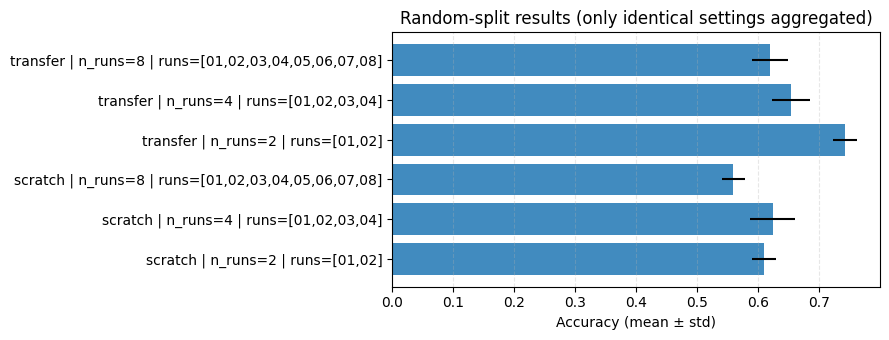

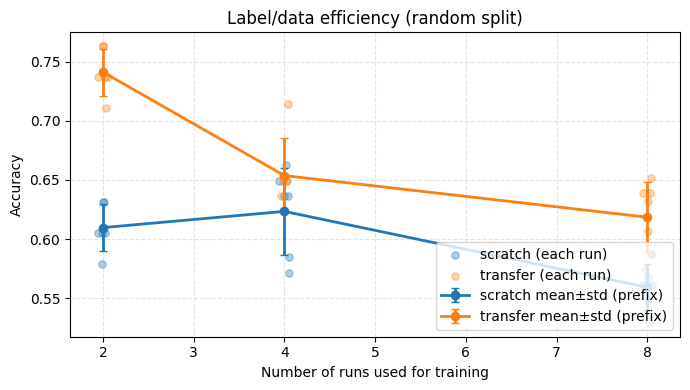

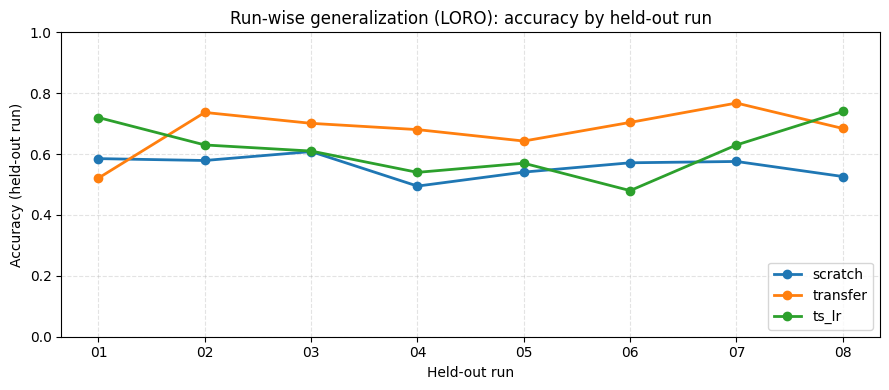

,mode,mean_acc,std_acc,n
1,transfer,0.679799,0.074192,8
2,ts_lr,0.615000,0.087014,8
0,scratch,0.560183,0.036730,8


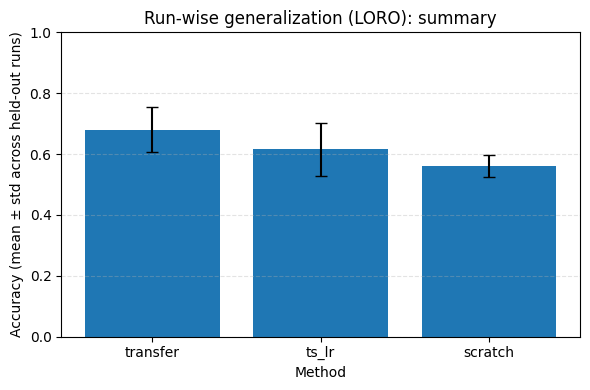

In [5]:
# Plot 1: Random-split summary + learning curve (from CSV)

df_rand = df[df['split'] == 'random_stratified'].copy()

if df_rand.empty:
    print("No random-split rows found (split=random_stratified).")
else:
    # Summary table (conservative: identical run-set only)
    summary = (
        df_rand.groupby(['mode', 'n_runs', 'runs_key'])
              .agg(count=('val_accuracy', 'size'), mean_acc=('val_accuracy', 'mean'), std_acc=('val_accuracy', 'std'))
              .reset_index()
              .sort_values(['mode', 'n_runs', 'runs_key'])
    )
    display(summary)

    # Bar: mean ± std per configuration
    plt.figure(figsize=(9, max(3.5, 0.3 * len(summary))))
    labels = summary.apply(lambda r: f"{r['mode']} | n_runs={int(r['n_runs'])} | runs=[{r['runs_key']}]", axis=1)
    plt.barh(range(len(summary)), summary['mean_acc'], xerr=summary['std_acc'].fillna(0.0), alpha=0.85)
    plt.yticks(range(len(summary)), labels)
    plt.xlabel('Accuracy (mean ± std)')
    plt.title('Random-split results (only identical settings aggregated)')
    plt.grid(True, axis='x', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Learning curve (prefix-only conservative aggregation)
    plt.figure(figsize=(7, 4))
    rng = np.random.RandomState(0)
    for mode, sub in df_rand.groupby('mode'):
        x = sub['n_runs'].to_numpy(dtype=float)
        y = sub['val_accuracy'].to_numpy(dtype=float)
        jitter = (rng.rand(len(x)) - 0.5) * 0.12
        plt.scatter(x + jitter, y, alpha=0.35, s=28, label=f"{mode} (each run)")

    prefix_df = df_rand[df_rand['is_prefix_01_to_k']].copy()
    if not prefix_df.empty:
        agg = (
            prefix_df.groupby(['mode', 'n_runs'])
                     .agg(mean_acc=('val_accuracy', 'mean'), std_acc=('val_accuracy', 'std'))
                     .reset_index()
        )
        for mode, sub in agg.groupby('mode'):
            sub = sub.sort_values('n_runs')
            plt.errorbar(sub['n_runs'], sub['mean_acc'], yerr=sub['std_acc'], marker='o', capsize=3, linewidth=2, label=f"{mode} mean±std (prefix)")

    plt.xlabel('Number of runs used for training')
    plt.ylabel('Accuracy')
    plt.title('Label/data efficiency (random split)')
    plt.grid(True, linestyle='--', alpha=0.35)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


# Plot 2: Run-wise generalization (LORO) from CSV

df_loro = df[df['notes'].astype(str).str.contains('split=leave_one_run_out', na=False)].copy()
if df_loro.empty:
    print("No run-wise LORO rows found (split=leave_one_run_out).")
else:
    df_loro = df_loro[df_loro['mode'].isin(['scratch', 'transfer', 'ts_lr'])].copy()
    # test_run already parsed above, but ensure present
    df_loro['test_run'] = df_loro['notes'].astype(str).apply(lambda s: _note_field(s, 'test_run'))

    pivot = df_loro.pivot_table(index='test_run', columns='mode', values='val_accuracy', aggfunc='mean').reset_index()
    pivot = pivot.sort_values('test_run')

    plt.figure(figsize=(9, 4))
    for mode, style in [('scratch', '-o'), ('transfer', '-o'), ('ts_lr', '-o')]:
        if mode in pivot.columns:
            plt.plot(pivot['test_run'], pivot[mode], style, linewidth=2, label=mode)
    plt.ylim(0.0, 1.0)
    plt.xlabel('Held-out run')
    plt.ylabel('Accuracy (held-out run)')
    plt.title('Run-wise generalization (LORO): accuracy by held-out run')
    plt.grid(True, linestyle='--', alpha=0.35)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    summary_loro = (
        df_loro.groupby('mode')
               .agg(mean_acc=('val_accuracy', 'mean'), std_acc=('val_accuracy', 'std'), n=('val_accuracy', 'size'))
               .reset_index()
               .sort_values('mean_acc', ascending=False)
    )
    display(summary_loro)

    plt.figure(figsize=(6, 4))
    plt.bar(summary_loro['mode'], summary_loro['mean_acc'], yerr=summary_loro['std_acc'], capsize=4)
    plt.ylim(0.0, 1.0)
    plt.xlabel('Method')
    plt.ylabel('Accuracy (mean ± std across held-out runs)')
    plt.title('Run-wise generalization (LORO): summary')
    plt.grid(True, axis='y', linestyle='--', alpha=0.35)
    plt.tight_layout()
    plt.show()


## Discussion [15 pts]

Evaluate the results of your project including 
* Why should I believe that your numerical results are correct (convergence, test cases etc)?
* Did the project work (in your opinion)?
* If yes:  what would be the next steps to try
* If no:  Explain why your approach did not work and what you might do to fix it.


### Why the results are credible
- **Sanity/controls**: The classical baseline evaluation includes a **label-shuffle control** that produces near-chance performance, supporting that the above-chance TS+LR results reflect real structure in the data rather than leakage.
- **Repeatability**: I ran multiple training jobs per condition and summarized mean ± std (visible in the summary plots). This shows that conclusions (transfer > scratch, especially at low data) are not a single lucky run.
- **Uncertainty estimates**: Bootstrap confidence intervals on the validation predictions provide an additional check on effect size.
- **Stronger generalization test**: I additionally ran **run-wise generalization (LORO/holdout)**, which reduces the chance that performance is inflated by mixing temporally adjacent trials from the same run across train/val.

### Did the project work?
Yes. The core hypothesis—**transfer learning improves label efficiency on consumer EEG**—is supported. Transfer models achieved higher validation accuracy than scratch models across multiple run subsets, with the largest gains when training data is smallest (2 runs). Classical baselines were competitive but generally slightly behind the best transfer models.

The run-wise results strengthen the conclusion: there is clear **run-to-run drift**, but **transfer remains best on average** across held-out runs, and TS+LR remains a competitive baseline (sometimes winning on specific held-out runs).

### What I learned
- Classical covariance/tangent-space methods remain strong and are excellent for small-data baselines.
- A compact deep model can exceed classical performance, but the margin is modest unless **transfer learning** is used.
- Visual summaries (learning curves, per-run scatter, confusion matrices) are essential to interpret small accuracy gaps and variability.
- Run-wise evaluation is an important reality check: it shows which runs are “hard” and highlights nonstationarity that random splits can hide.

### Limitations
- Results are currently strongest for a single subject/session; cross-session replication would strengthen conclusions.
- Run-wise generalization is still within one subject and one recording setup; generalization across days/headset setups is not yet tested.

### Next steps
- **Cross-session / cross-day replication**: record additional sessions and repeat the full analysis (including run-wise splits).
- **Domain adaptation improvements**: explicitly adapt channel mappings and normalization between public and consumer EEG (e.g., learn a lightweight linear mapping or use alignment losses).
- **Calibration / reliability**: report balanced accuracy, AUC, and calibration (ECE) to understand decision confidence in real-time settings.

Overall, the project provides a reproducible baseline and a clearer picture of robustness by including both random-split and run-wise generalization evaluations.